# Introduction to Machine Learning — Part 2: Guided Walkthrough

**Dataset:** `heart.csv` (UCI Heart Disease, 303 patients, 14 features).
**Goal:** Build, evaluate, and audit a classifier that predicts whether a patient has heart disease from clinical measurements.

By the end of this notebook you will have:

1. Loaded and explored a real medical dataset.
2. Trained two classifiers (Logistic Regression and Random Forest).
3. Evaluated them with accuracy, a confusion matrix, a classification report, an ROC curve and AUC, and a precision-recall curve.
4. Tuned the decision threshold for a clinical use case.
5. Run a fairness audit comparing performance by sex.

Read each text cell before running the code that follows it. The narrative matters as much as the numbers.


## 1. Why heart disease?

Cardiovascular disease is the leading cause of death globally and a growing burden in sub-Saharan Africa, including Ghana. The World Health Organization estimates 17.9 million CVD deaths in 2019, with over three quarters in low- and middle-income countries. Early identification of at-risk patients lets clinicians intervene before an event.

The UCI Heart Disease dataset contains 303 anonymised patient records from the Cleveland Clinic study, each with 13 clinical features and a binary `target`:

- `target = 1`: heart disease present
- `target = 0`: heart disease absent

The dataset is small by modern standards. Treat results in this notebook as illustrative, not clinically actionable.

**Source:** `heart.csv` is bundled in this folder. The original UCI page: https://archive.ics.uci.edu/dataset/45/heart+disease


## 2. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


## 3. Load and inspect

In [2]:
df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
df.head()


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### Data dictionary

| Column | Meaning |
|---|---|
| `age` | Age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest-pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true) |
| `restecg` | Resting ECG result (0–2) |
| `thalach` | Max heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment (0–2) |
| `ca` | Number of major vessels coloured by fluoroscopy (0–4) |
| `thal` | Thalassemia (0–3) |
| `target` | 1 = heart disease, 0 = no disease |

Several "numeric" columns are actually encoded categorical variables (`cp`, `restecg`, `slope`, `thal`). We will treat them as numeric here for simplicity, but in a clinical project they should be one-hot encoded.


## 4. Exploratory Data Analysis

Before modelling we want to know:

- Is the target balanced or skewed?
- How is sex distributed, and does prevalence differ by sex?
- Which features look most associated with the target?
- Are there obvious data-quality issues?


target
0    138
1    165
Name: count, dtype: int64
Positive rate: 54.5%


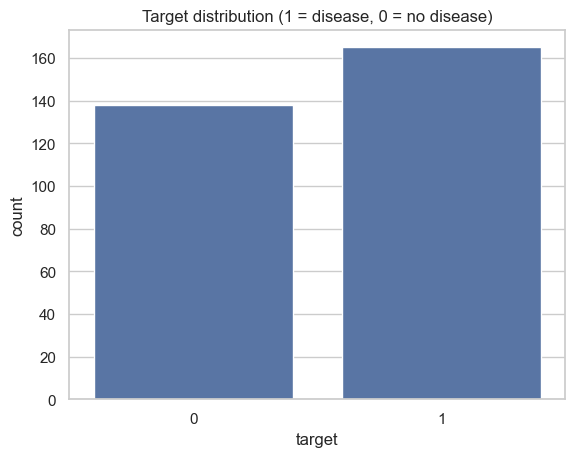

In [4]:
# Target balance
target_counts = df["target"].value_counts().sort_index()
print(target_counts)
print(f"Positive rate: {df['target'].mean():.1%}")

ax = sns.countplot(x="target", data=df)
ax.set_title("Target distribution (1 = disease, 0 = no disease)")
plt.show()


The target is roughly balanced (~54% positive). Accuracy is therefore a reasonable headline metric — but we will still report precision and recall, because the *clinical* cost of a false negative is much higher than a false positive.

     count  disease_rate
sex                     
0       96      0.750000
1      207      0.449275


/var/folders/pp/hz_f587d7vq4y29_26dtwdjh0000gn/T/ipykernel_87401/1436306924.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Female (0)", "Male (1)"])


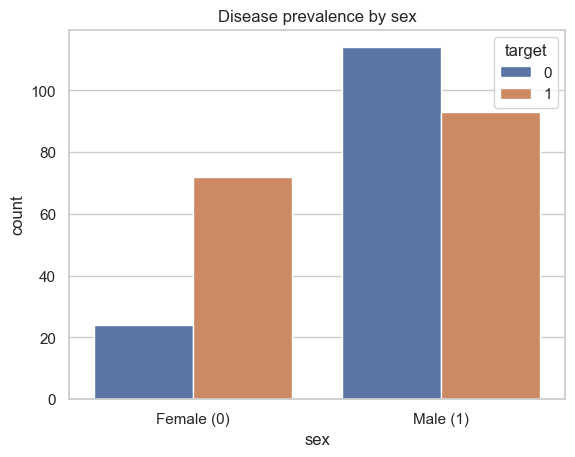

In [5]:
# Sex distribution and disease rate by sex
print(df.groupby("sex")["target"].agg(["count", "mean"]).rename(columns={"mean": "disease_rate"}))

ax = sns.countplot(x="sex", hue="target", data=df)
ax.set_xticklabels(["Female (0)", "Male (1)"])
ax.set_title("Disease prevalence by sex")
plt.show()


**Representation bias warning.** The dataset is roughly two-thirds male (207) and one-third female (96). Disease prevalence also differs sharply by sex in this sample. Whatever we learn, performance on female patients will be estimated from far fewer examples — we will revisit this in the fairness audit at the end.

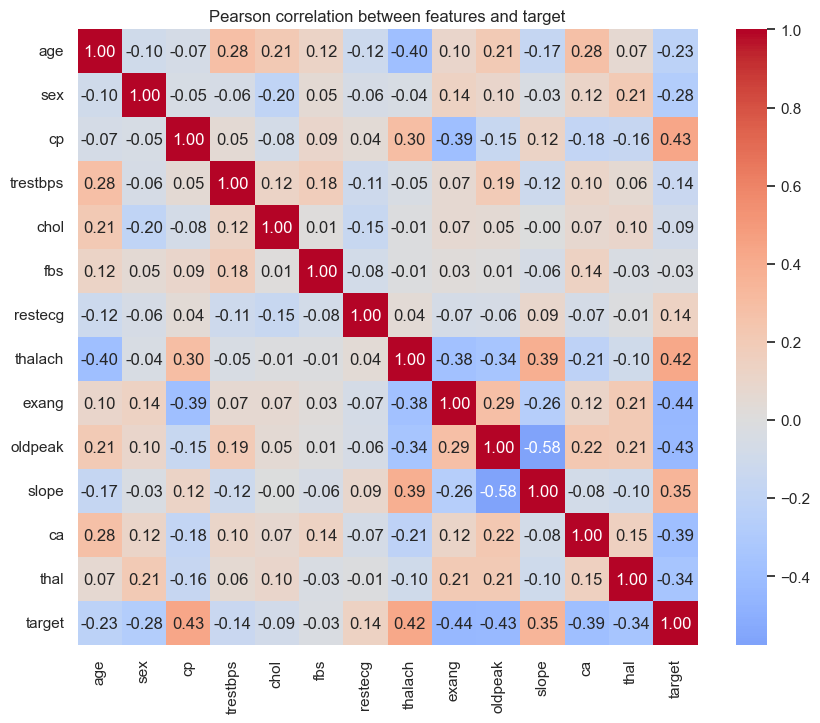

In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson correlation between features and target")
plt.show()


Reading the bottom row (`target`): the strongest linear associations are with `cp` (chest-pain type), `thalach` (max heart rate), `oldpeak`, `exang`, and `ca`. Several of these match clinical intuition. None is so dominant that we can predict the target from a single feature — which is why we use a model.

## 5. Preprocessing

Steps:

1. Separate features (`X`) from the target (`y`).
2. Hold out 20% as a test set, **stratified** by `target` so both splits keep the same class balance.
3. Standardise the numeric features (mean 0, std 1). Tree-based models do not need scaling, but Logistic Regression does — and scaling never hurts a fair comparison.


In [7]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.1%}, Test positive rate: {y_test.mean():.1%}")


Train: (242, 13), Test: (61, 13)
Train positive rate: 54.5%, Test positive rate: 54.1%


## 6. Baseline model — Logistic Regression

Logistic Regression is the right starting point for binary classification. It is fast, the coefficients are interpretable, and it provides a strong baseline that any more complex model has to beat.


In [8]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print(f"Test accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")


Test accuracy: 0.803


## 7. Evaluation in depth

Accuracy alone tells us very little. We will look at the confusion matrix, precision/recall/F1, the ROC curve, the precision-recall curve, and the effect of changing the decision threshold.

### 7.1 Confusion matrix


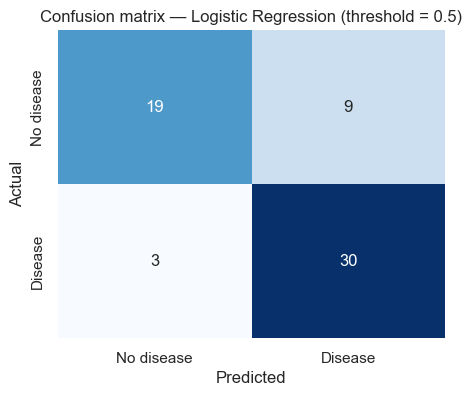

True negatives:  19
False positives: 9  (healthy patients flagged as sick)
False negatives: 3  (sick patients missed)
True positives:  30


In [9]:
cm = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No disease", "Disease"],
    yticklabels=["No disease", "Disease"],
    cbar=False,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix — Logistic Regression (threshold = 0.5)")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives:  {tn}")
print(f"False positives: {fp}  (healthy patients flagged as sick)")
print(f"False negatives: {fn}  (sick patients missed)")
print(f"True positives:  {tp}")


**Clinical reading.** Each false negative is a patient with heart disease who was told they were healthy. In a real screening context that is the most expensive kind of error. We want to drive `fn` down, even if it costs us a few extra `fp` (which only mean a follow-up test, not a missed diagnosis).

### 7.2 Classification report

In [10]:
print(classification_report(y_test, y_pred_lr, target_names=["No disease", "Disease"]))


              precision    recall  f1-score   support

  No disease       0.86      0.68      0.76        28
     Disease       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



### 7.3 ROC curve and AUC

The ROC curve plots true-positive rate against false-positive rate as we sweep the decision threshold from 1.0 down to 0.0. AUC = 1.0 is perfect, AUC = 0.5 is random.


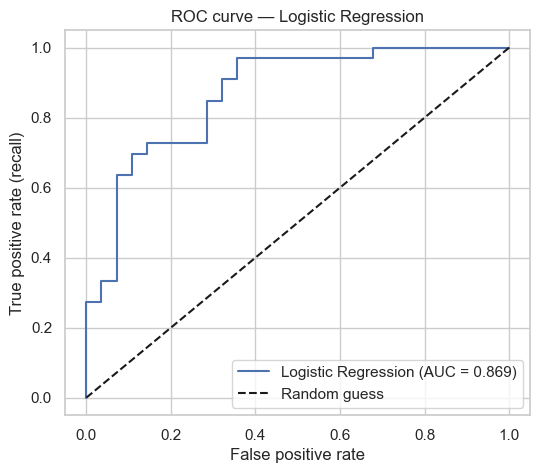

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (recall)")
plt.title("ROC curve — Logistic Regression")
plt.legend(loc="lower right")
plt.show()


### 7.4 Precision-Recall curve

For an imbalanced problem the PR curve is often more informative than ROC. Even when classes are roughly balanced (as here), the PR curve makes the precision-recall trade-off explicit.


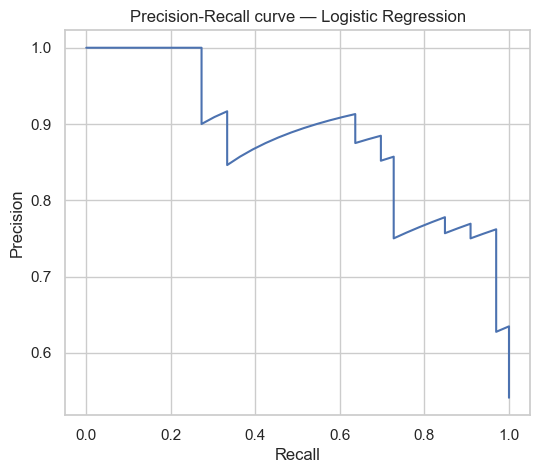

In [12]:
prec, rec, pr_thresholds = precision_recall_curve(y_test, y_proba_lr)

plt.figure(figsize=(6, 5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve — Logistic Regression")
plt.show()


### 7.5 Threshold tuning

Default `predict()` uses threshold = 0.5. For a screening tool we want high recall — we are willing to call back some healthy patients to avoid missing a sick one. Let us see what threshold delivers recall ≥ 0.95 and what precision we pay for it.


In [13]:
rows = []
for t in np.arange(0.10, 0.91, 0.05):
    pred_t = (y_proba_lr >= t).astype(int)
    cm_t = confusion_matrix(y_test, pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    rows.append({"threshold": round(t, 2), "precision": precision, "recall": recall, "fp": fp, "fn": fn})

threshold_table = pd.DataFrame(rows)
threshold_table


,threshold,precision,recall,fp,fn
0,0.10,0.653061,0.969697,17,1
1,0.15,0.727273,0.969697,12,1
2,0.20,0.761905,0.969697,10,1
3,0.25,0.761905,0.969697,10,1
4,0.30,0.756098,0.939394,10,2
5,0.35,0.756098,0.939394,10,2
6,0.40,0.750000,0.909091,10,3
7,0.45,0.769231,0.909091,9,3
8,0.50,0.769231,0.909091,9,3
9,0.55,0.763158,0.878788,9,4


Pick the row where recall first crosses 0.95. That is the threshold a screening clinic might pick — accepting more false positives (extra follow-up tests) in exchange for catching almost every diseased patient. The default 0.5 threshold is a software convention, not a clinical decision.

## 8. A second model — Random Forest

Random Forest is an ensemble of decision trees. It captures non-linear interactions between features without manual feature engineering, and it gives us a built-in feature-importance ranking.


In [14]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)  # tree models do not require scaled features

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(f"Random Forest accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(classification_report(y_test, y_pred_rf, target_names=["No disease", "Disease"]))


Random Forest accuracy: 0.836
              precision    recall  f1-score   support

  No disease       0.95      0.68      0.79        28
     Disease       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



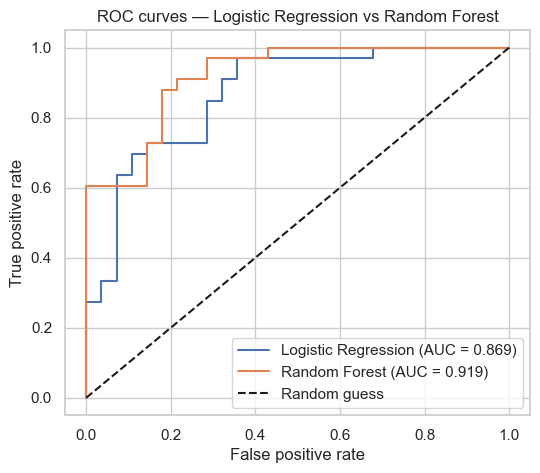

In [15]:
# ROC comparison
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves — Logistic Regression vs Random Forest")
plt.legend(loc="lower right")
plt.show()


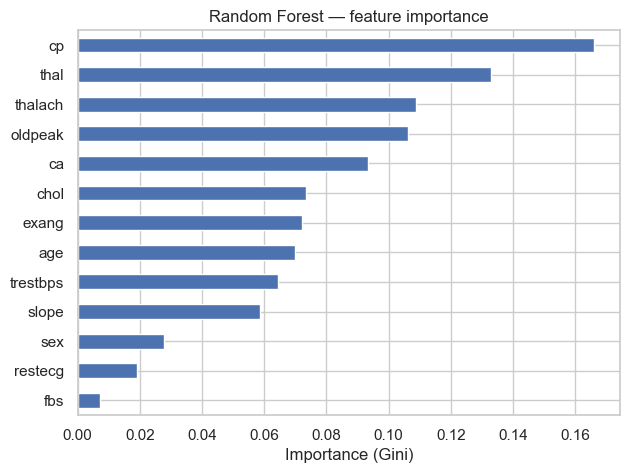

In [16]:
# Feature importance from the Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(7, 5))
importances.plot(kind="barh")
plt.xlabel("Importance (Gini)")
plt.title("Random Forest — feature importance")
plt.show()


The features the model leans on most heavily (`cp`, `thalach`, `oldpeak`, `ca`) align with clinical knowledge. That is reassuring; a sensible model uses sensible features.

## 9. Fairness audit — performance by sex

Overall numbers can hide subgroup failures. Let us split the test set by `sex` and report metrics separately.


In [17]:
audit = X_test.copy()
audit["actual"] = y_test.values
audit["pred"] = y_pred_lr  # use Logistic Regression predictions

def subgroup_metrics(group):
    tn, fp, fn, tp = confusion_matrix(group["actual"], group["pred"], labels=[0, 1]).ravel()
    n = len(group)
    accuracy = (tp + tn) / n if n else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    return pd.Series({"n": n, "accuracy": accuracy, "precision": precision, "recall": recall})

by_sex = audit.groupby("sex").apply(subgroup_metrics)
by_sex.index = ["Female (0)", "Male (1)"]
by_sex


,n,accuracy,precision,recall
Female (0),19.0,0.894737,0.937500,0.937500
Male (1),42.0,0.761905,0.652174,0.882353


**How to read this table.** Compare the `recall` column across rows. A large gap means the model misses the disease more often for one sex than the other — a fairness problem the headline accuracy hides. Note the `n` column: female patients are the smaller group, so the metric is also noisier.

Possible mitigations (out of scope for this notebook): collect more data on under-represented groups, train separate models per group, apply a fairness-aware learning algorithm, or — sometimes — accept a small accuracy drop in exchange for parity.


## 10. Wrap-up

What we built:

- A complete supervised pipeline from raw CSV to evaluated, audited classifier.
- Two models compared on the same test set with multiple metrics.
- A threshold-tuning analysis grounded in a real clinical use case.
- A fairness audit that surfaces subgroup performance differences.

What we did not do (and you should before deploying anything similar):

- Cross-validation. Our test set is 60 patients; a single split is high-variance. See exercise 6 in Part 3.
- Hyperparameter tuning with a validation set or grid search.
- Calibration of predicted probabilities (clinically important).
- External validation on a different hospital's data — the most important test of all.

Continue to **`03_Exercises_and_Challenges.ipynb`** to practise these techniques on your own.
